# Training — Autoencoder (AE)

<div style="text-align: justify">

The following notebook trains a symmetric <b>Autoencoder (AE)</b> for the <b>Tau Anomaly Detection</b> analysis. The model is trained on <b>background-only</b> events using PyTorch Lightning. After training, per-event anomaly scores (reconstruction errors) are computed on the predict set and persisted for downstream evaluation. Experiment metrics are tracked with <b>Weights & Biases</b>.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| DataModule | `datamodule.AnomalyDataModule` | Read mc.parquet, split bkg/sig, fit scaler, build dataloaders |
| Model | `ae.Autoencoder` | Instantiate symmetric AE from config |
| Logger | `WandbLogger` | Initialise Weights & Biases experiment tracking |
| Train | `lightning.Trainer` | Fit model with early stopping and checkpointing |
| Curves | `plots.plot_loss` | Training and validation loss curves |
| Scores | `anomaly.reconstruction_error` | Compute per-event anomaly scores on predict set |
| Save | `trainer.save_checkpoint`, `scores_df.to_parquet` | Persist model checkpoint and scores parquet |

The same pipeline is available as a CLI via `uv run python run.py stage=train model=ae`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)

Machine Learning:
* [PyTorch](https://pytorch.org/)
* [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/)

Experiment Tracking:
* [Weights & Biases](https://wandb.ai/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration with the AE model config.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config", overrides=["model=ae"])

Resolving input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "ae"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## DataModule

Setting up the `AnomalyDataModule`. It reads the MC parquet, separates background from signal, fits a scaler on the background training split, and builds `TensorDataset` objects that pair features with event weights.

In [6]:
import lightning as L

L.seed_everything(cfg.seed, workers=True)

Seed set to 1


1

In [7]:
from src.models.datamodule import AnomalyDataModule

background_origins = {
    s["id"]
    for s in cfg.samples.background.samples
    if s["id"] not in set(cfg.samples.background.get("exclude", []))
}
print(f"Background origins: {background_origins}")

dm = AnomalyDataModule(
    mc_path=str(dataframes_dir / "mc.parquet"),
    background_origins=background_origins,
    normalization=cfg.model.normalization,
    val_fraction=cfg.pipeline.val_fraction,
    batch_size=cfg.model.batch_size,
    seed=cfg.seed,
)
dm.setup()
print(f"Features: {dm.n_features}")
print(f"Feature names: {dm.feature_names_}")

Background origins: {'singletop', 'ttX', 'wmunu', 'wtaunu', 'zmumu', 'znunu', 'diboson', 'ttbar', 'ztautau', 'zee', 'wenu'}
Features: 53
Feature names: ['nVtx', 'LeptonVeto', 'jet_n', 'jet_n_btag', 'sumMTJet', 'sumMTTauJet', 'met', 'met_phi', 'METSig', 'meff', 'ht', 'ele_n', 'mu_n', 'Mt2_taumu', 'Mt2_tauel', 'Mtaumu', 'Mtauel', 'tau_pt_0', 'tau_eta_0', 'tau_phi_0', 'tau_charge_0', 'tau_ntracks_0', 'tau_nIsolatedTracks_0', 'tau_nAllTracks_0', 'tau_width_0', 'tau_jetpt_0', 'tau_delPhiMet_0', 'tau_mtMet_0', 'tau_NNDecayMode_0', 'jet_pt_0', 'jet_pt_1', 'jet_pt_2', 'jet_eta_0', 'jet_eta_1', 'jet_eta_2', 'jet_phi_0', 'jet_phi_1', 'jet_phi_2', 'jet_mtMet_0', 'jet_mtMet_1', 'jet_mtMet_2', 'jet_isBjet_0', 'jet_isBjet_1', 'jet_isBjet_2', 'jet_jvt_0', 'jet_jvt_1', 'jet_jvt_2', 'jet_delPhiMet_0', 'jet_delPhiMet_1', 'jet_delPhiMet_2', 'jet_width_0', 'jet_width_1', 'jet_width_2']


## Model

Instantiating the Autoencoder from the typed config. The architecture mirrors the encoder in reverse for the decoder.

In [8]:
from omegaconf import OmegaConf

from src.models.ae import Autoencoder
from src.models.config import AEConfig

model_params = dict(OmegaConf.to_container(cfg.model, resolve=True))
model_cfg = AEConfig(**model_params)
model = Autoencoder(model_cfg, n_features=dm.n_features)

n_params = sum(p.numel() for p in model.parameters())
print(f"Autoencoder: {n_params:,} parameters")
print(model)

Autoencoder: 326,213 parameters
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=53, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=53, bias=True)
  )
  (loss_fn): MSELoss()
)


## Training

### WandB Logger

Initialising the Weights & Biases logger. Set `enabled: false` in `configs/pipeline/default.yaml` to disable tracking.

In [9]:
from lightning.pytorch.loggers import WandbLogger

wandb_cfg = cfg.pipeline.wandb
if wandb_cfg.enabled:
    wandb_logger = WandbLogger(
        project=wandb_cfg.project,
        name=f"{cfg.experiment_name}-ae",
        log_model=wandb_cfg.log_model,
        config=dict(OmegaConf.to_container(cfg.model, resolve=True)),
    )
else:
    wandb_logger = False

print(f"WandB logging: {'enabled' if wandb_cfg.enabled else 'disabled'}")

WandB logging: enabled


### Trainer

Creating the Lightning Trainer with early stopping and model checkpointing.

In [10]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from src.models.callbacks import EpochProgressBar, MetricTracker

tracker = MetricTracker()

callbacks = [
    EarlyStopping(
        monitor=cfg.pipeline.monitor_metric,
        mode=cfg.pipeline.monitor_mode,
        patience=cfg.pipeline.early_stopping_patience,
        verbose=False,
    ),
    ModelCheckpoint(
        dirpath=models_dir,
        filename="ae-best",
        monitor=cfg.pipeline.monitor_metric,
        mode=cfg.pipeline.monitor_mode,
        save_top_k=1,
        verbose=False,
    ),
    EpochProgressBar(),
    tracker,
]

trainer = L.Trainer(
    max_epochs=cfg.model.n_epochs,
    callbacks=callbacks,
    logger=wandb_logger,
    deterministic=True,
    precision="16-mixed" if cfg.model.amp else "32-true",
    enable_progress_bar=False,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Fit

Training the autoencoder on background-only data.

In [11]:
trainer.fit(model, datamodule=dm)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | encoder | Sequential | 163 K  | train | 0    
1 | decoder | Sequential | 163 K  | train | 0    
2 | loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------
326 K     Trainable params
0         Non-trainable params
326 K     Total params
1.305     Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode
0         Total Flops


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

### Checkpoint

Saving the best checkpoint (lowest validation loss) as the canonical `ae.ckpt`. If early stopping triggered, this is the checkpoint from the best epoch, not the final epoch.

In [ ]:
import shutil
from pathlib import Path

import torch

best_model_path = getattr(trainer.checkpoint_callback, "best_model_path", "")
ckpt_path = models_dir / "ae.ckpt"

if best_model_path:
    shutil.copy2(best_model_path, ckpt_path)
    best_ckpt = torch.load(best_model_path, weights_only=False, map_location="cpu")
    model.load_state_dict(best_ckpt["state_dict"])
    print(f"Saved best checkpoint ({Path(best_model_path).name}) as {ckpt_path.relative_to(path)}")
else:
    trainer.save_checkpoint(ckpt_path)
    print(f"Saved final checkpoint: {ckpt_path.relative_to(path)}")

## Training Curves

Plotting train and validation loss over epochs.

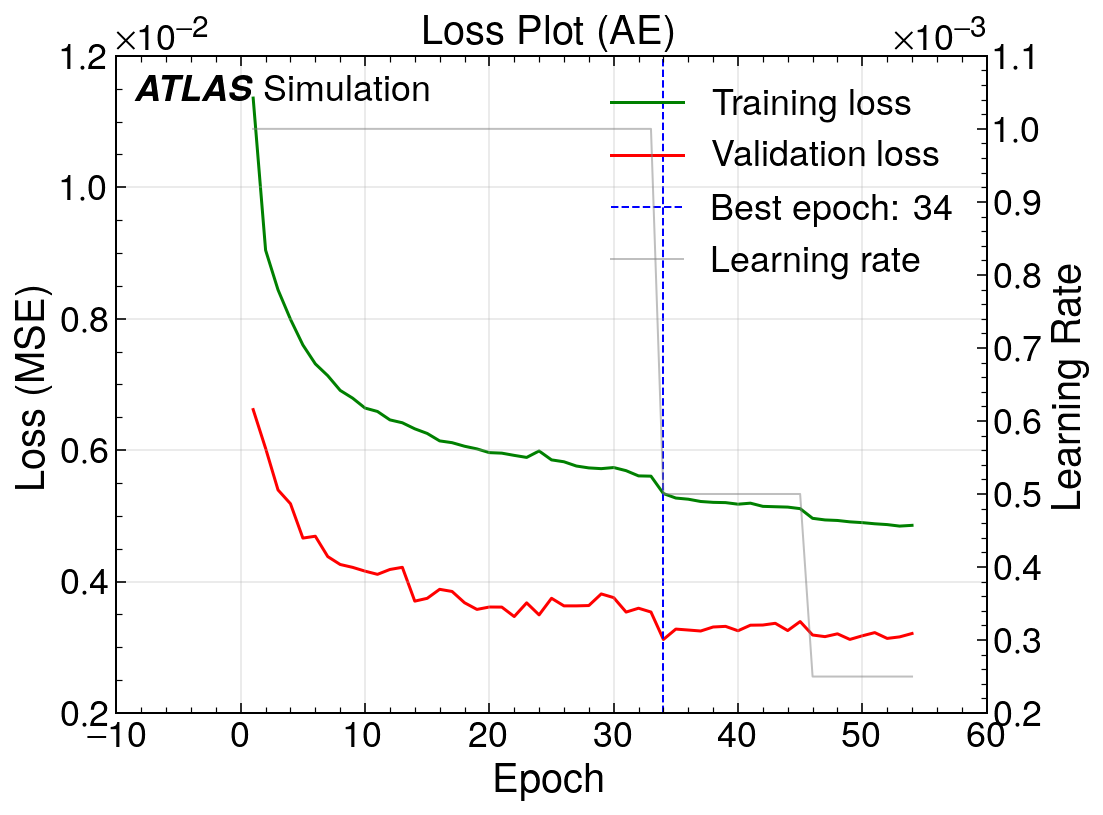

In [13]:
from src.models.plots import plot_loss

fig = plot_loss(tracker.history["train_loss"], tracker.history["val_loss"], title="Loss Plot (AE)", lr=tracker.history.get("lr"))
fig.savefig(plots_dir / "ae_loss.png")

## Anomaly Scores

Computing reconstruction error on the predict set (background validation + signal). Higher reconstruction error indicates a more anomalous event. The scores are persisted as a parquet file for downstream evaluation.

In [14]:
import torch
import numpy as np

from src.models.anomaly import reconstruction_error, build_scores_frame

predictions = trainer.predict(model, datamodule=dm)
x_hat = torch.cat(predictions)
x_orig = torch.cat([batch[0] for batch in dm.predict_dataloader()])

scores = reconstruction_error(x_orig, x_hat).numpy()
print(f"Scores: {len(scores):,} events")
print(f"  Background mean: {scores[dm.predict_labels == 0].mean():.6f}")
print(f"  Signal mean:     {scores[dm.predict_labels == 1].mean():.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]


Scores: 5,124,922 events
  Background mean: 0.146477
  Signal mean:     0.413942


## Serialization

Saving the anomaly scores DataFrame for downstream evaluation. The trained model checkpoint was saved above.

In [ ]:
scores_df = build_scores_frame(
    scores, dm.predict_labels, dm.predict_origins, dm.predict_sample_types
)
scores_path = dataframes_dir / "ae_scores.parquet"
scores_df.to_parquet(scores_path)
scores_df.head()

### Finish WandB

Closing the WandB run. All metrics and artifacts have been logged.

In [16]:
import wandb

if wandb.run is not None:
    wandb.finish()